# S&P 500 Companies with Financial Information

**Variables financieras:**
*   Price
*   Price to Earnings (PE)
*   Dividend Yield
*   Earnings Per Share (EPS)
*   52 Week High
*   52 Week Low
*   Market Cap
*   EMBITDA
*   Price to Sales (PS)
*   Price to Book (PB)

**Variables descriptivas:**
*   Symbol
*   Name
*   Sector





In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
from sklearn.preprocessing import RobustScaler
import plotly.express as px

**Carga de datos**

In [8]:
df = pd.read_csv('finances.csv')
df.head()

,Symbol,Name,Sector,Price,Price/Earnings,Dividend Yield,Earnings/Share,52 Week Low,52 Week High,Market Cap,EBITDA,Price/Sales,Price/Book,SEC Filings
0,MMM,3M Company,Industrials,222.89,24.31,2.332862,7.92,259.77,175.490,1.387211e+11,9.048000e+09,4.390271,11.34,http://www.sec.gov/cgi-bin/browse-edgar?action...
1,AOS,A.O. Smith Corp,Industrials,60.24,27.76,1.147959,1.70,68.39,48.925,1.078342e+10,6.010000e+08,3.575483,6.35,http://www.sec.gov/cgi-bin/browse-edgar?action...
2,ABT,Abbott Laboratories,Health Care,56.27,22.51,1.908982,0.26,64.60,42.280,1.021210e+11,5.744000e+09,3.740480,3.19,http://www.sec.gov/cgi-bin/browse-edgar?action...
3,ABBV,AbbVie Inc.,Health Care,108.48,19.41,2.499560,3.29,125.86,60.050,1.813863e+11,1.031000e+10,6.291571,26.14,http://www.sec.gov/cgi-bin/browse-edgar?action...
4,ACN,Accenture plc,Information Technology,150.51,25.47,1.714470,5.44,162.60,114.820,9.876586e+10,5.643228e+09,2.604117,10.62,http://www.sec.gov/cgi-bin/browse-edgar?action...


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 505 entries, 0 to 504
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Symbol          505 non-null    str    
 1   Name            505 non-null    str    
 2   Sector          505 non-null    str    
 3   Price           505 non-null    float64
 4   Price/Earnings  503 non-null    float64
 5   Dividend Yield  505 non-null    float64
 6   Earnings/Share  505 non-null    float64
 7   52 Week Low     505 non-null    float64
 8   52 Week High    505 non-null    float64
 9   Market Cap      505 non-null    float64
 10  EBITDA          505 non-null    float64
 11  Price/Sales     505 non-null    float64
 12  Price/Book      497 non-null    float64
 13  SEC Filings     505 non-null    str    
dtypes: float64(10), str(4)
memory usage: 104.2 KB


**Preprocesamiento y Análisis exploratorio**

In [10]:
#Detección de valores nulos
filas_con_nulos = df[df.isnull().any(axis=1)]
filas_con_nulos.head(20)

,Symbol,Name,Sector,Price,Price/Earnings,Dividend Yield,Earnings/Share,52 Week Low,52 Week High,Market Cap,EBITDA,Price/Sales,Price/Book,SEC Filings
55,ARNC,Arconic Inc,Industrials,24.45,20.21,0.956175,-0.21,31.17,21.755,1.212330e+10,1.517000e+09,0.942148,NaN,http://www.sec.gov/cgi-bin/browse-edgar?action...
199,FL,Foot Locker Inc,Consumer Discretionary,45.88,9.50,2.582795,4.91,77.86,28.420,5.819080e+09,9.570000e+08,1.036295,NaN,http://www.sec.gov/cgi-bin/browse-edgar?action...
225,HCA,HCA Holdings,Health Care,95.97,14.07,1.422764,5.94,106.84,71.180,3.444905e+10,8.202000e+09,0.725192,NaN,http://www.sec.gov/cgi-bin/browse-edgar?action...
292,MRO,Marathon Oil Corp.,Energy,15.68,-32.00,1.224740,-2.65,19.52,10.550,1.387501e+10,2.266000e+09,4.657876,NaN,http://www.sec.gov/cgi-bin/browse-edgar?action...
346,OXY,Occidental Petroleum,Energy,68.47,195.63,4.408186,-0.75,78.09,57.200,5.346769e+10,5.205000e+09,6.044895,NaN,http://www.sec.gov/cgi-bin/browse-edgar?action...
358,PEP,PepsiCo Inc.,Consumer Staples,110.15,21.51,2.837004,4.36,122.51,104.770,1.614133e+11,1.284300e+10,3.670506,NaN,http://www.sec.gov/cgi-bin/browse-edgar?action...
360,PRGO,Perrigo,Health Care,84.44,NaN,0.731261,-28.01,95.93,63.680,1.232638e+10,0.000000e+00,3.385007,2.03,http://www.sec.gov/cgi-bin/browse-edgar?action...
430,TPR,"Tapestry, Inc.",Consumer Discretionary,48.85,NaN,0.000000,2.09,50.71,36.690,1.424720e+10,0.000000e+00,4.078549,4.35,http://www.sec.gov/cgi-bin/browse-edgar?action...
450,TDG,TransDigm Group,Industrials,283.00,23.76,0.000000,7.92,321.38,203.720,1.524120e+10,1.635916e+09,4.268832,NaN,http://www.sec.gov/cgi-bin/browse-edgar?action...
460,UNP,Union Pacific,Industrials,124.86,22.06,2.062655,13.52,143.05,101.060,1.015133e+11,1.016900e+10,4.860507,NaN,http://www.sec.gov/cgi-bin/browse-edgar?action...


In [11]:
#Tratamiento de valores nulos
#Imputación por sector
df['Price/Book'] = df.groupby('Sector')['Price/Book'].transform(lambda x: x.fillna(x.median()))
df['Price/Earnings'] = df.groupby('Sector')['Price/Earnings'].transform(lambda x: x.fillna(x.median()))

In [12]:
#Detecciónd e valores atípicos
def valores_atipicos(df, col, inferior, superior):
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)
  IQR = Q3 - Q1

  limite_inferior = Q1 - inferior * IQR
  limite_superior = Q3 + superior * IQR

  outliers = df[(df[col] < limite_inferior) | (df[col] > limite_superior)]

  total_validos = df[col].notnull().sum()
  porcentaje = (len(outliers) / total_validos * 100) if total_validos > 0 else 0

  return len(outliers), limite_inferior, limite_superior, porcentaje

lista_resumen = []

columnas_num = df.select_dtypes(include=['number']).columns
for col in columnas_num:
  outliers, limite_inferior, limite_superior, porcentaje = valores_atipicos(df, col, 1.5, 1.5)
  lista_resumen.append([col, outliers, porcentaje, limite_inferior, limite_superior])

lista_resumen = pd.DataFrame(lista_resumen, columns=['Columna', 'Outliers', 'Porcentaje', 'Limite Inferior', 'Limite Superior'])
lista_resumen

df.to_csv("./finances_clean.csv", index=False)

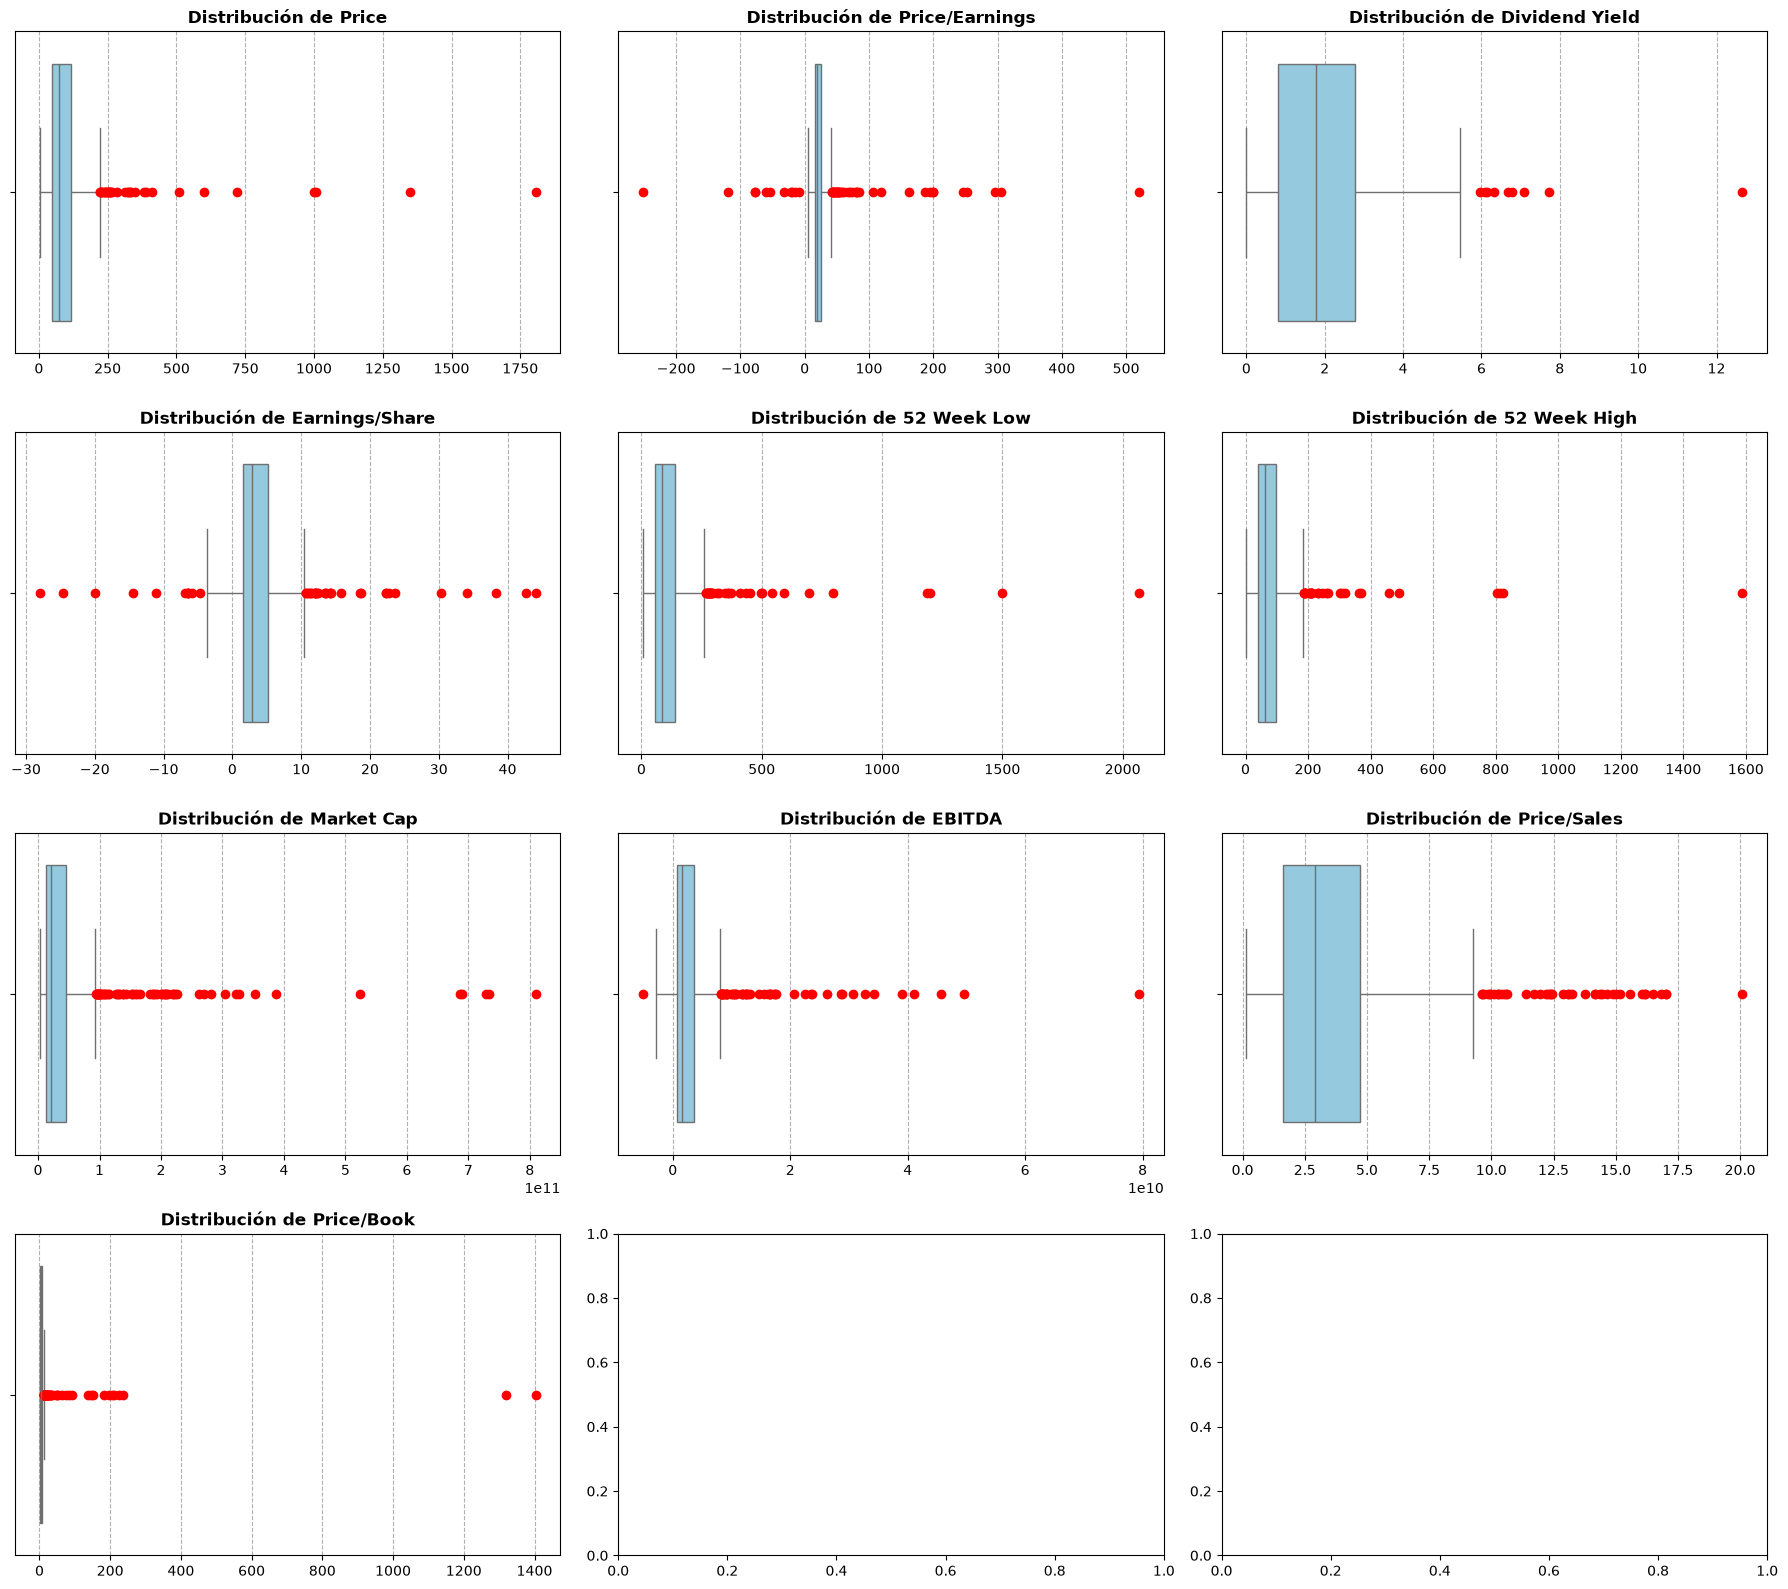

In [13]:
# Filtrado de las columnas con datos numéricos
#columnas_num = df.select_dtypes(include=['number']).columns
num_columnas = len(columnas_num)

# Cuadrícula con 3 gráficos por fila
filas = math.ceil(num_columnas / 3)
fig, axes = plt.subplots(filas, 3, figsize=(18, filas * 4))
axes = axes.flatten()

for i, col in enumerate(columnas_num):
    sns.boxplot(x=df[col], ax=axes[i], color='skyblue', flierprops={'markerfacecolor':'red', 'markeredgecolor':'red'})
    axes[i].set_title(f'Distribución de {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')  # Quitamos el label inferior
    axes[i].grid(axis='x', linestyle='--', alpha=1)

plt.tight_layout()
plt.show()

In [14]:
df.describe()

,Price,Price/Earnings,Dividend Yield,Earnings/Share,52 Week Low,52 Week High,Market Cap,EBITDA,Price/Sales,Price/Book
count,505.000000,505.000000,505.000000,505.000000,505.000000,505.000000,5.050000e+02,5.050000e+02,505.000000,505.000000
mean,103.830634,24.786762,1.895953,3.753743,122.623832,83.536616,4.923944e+10,3.590328e+09,3.941705,14.287307
std,134.427636,41.160620,1.537214,5.689036,155.362140,105.725473,9.005017e+10,6.840544e+09,3.460110,88.955835
min,2.820000,-251.530000,0.000000,-28.010000,6.590000,2.800000,2.626102e+09,-5.067000e+09,0.153186,0.510000
25%,46.250000,15.350000,0.794834,1.490000,56.250000,38.430000,1.273207e+10,7.739320e+08,1.629490,2.040000
50%,73.920000,19.450000,1.769255,2.890000,86.680000,62.850000,2.140095e+10,1.614399e+09,2.896440,3.460000
75%,116.540000,25.740000,2.781114,5.140000,140.130000,96.660000,4.511968e+10,3.692749e+09,4.703842,6.040000
max,1806.060000,520.150000,12.661196,44.090000,2067.990000,1589.000000,8.095080e+11,7.938600e+10,20.094294,1403.380000


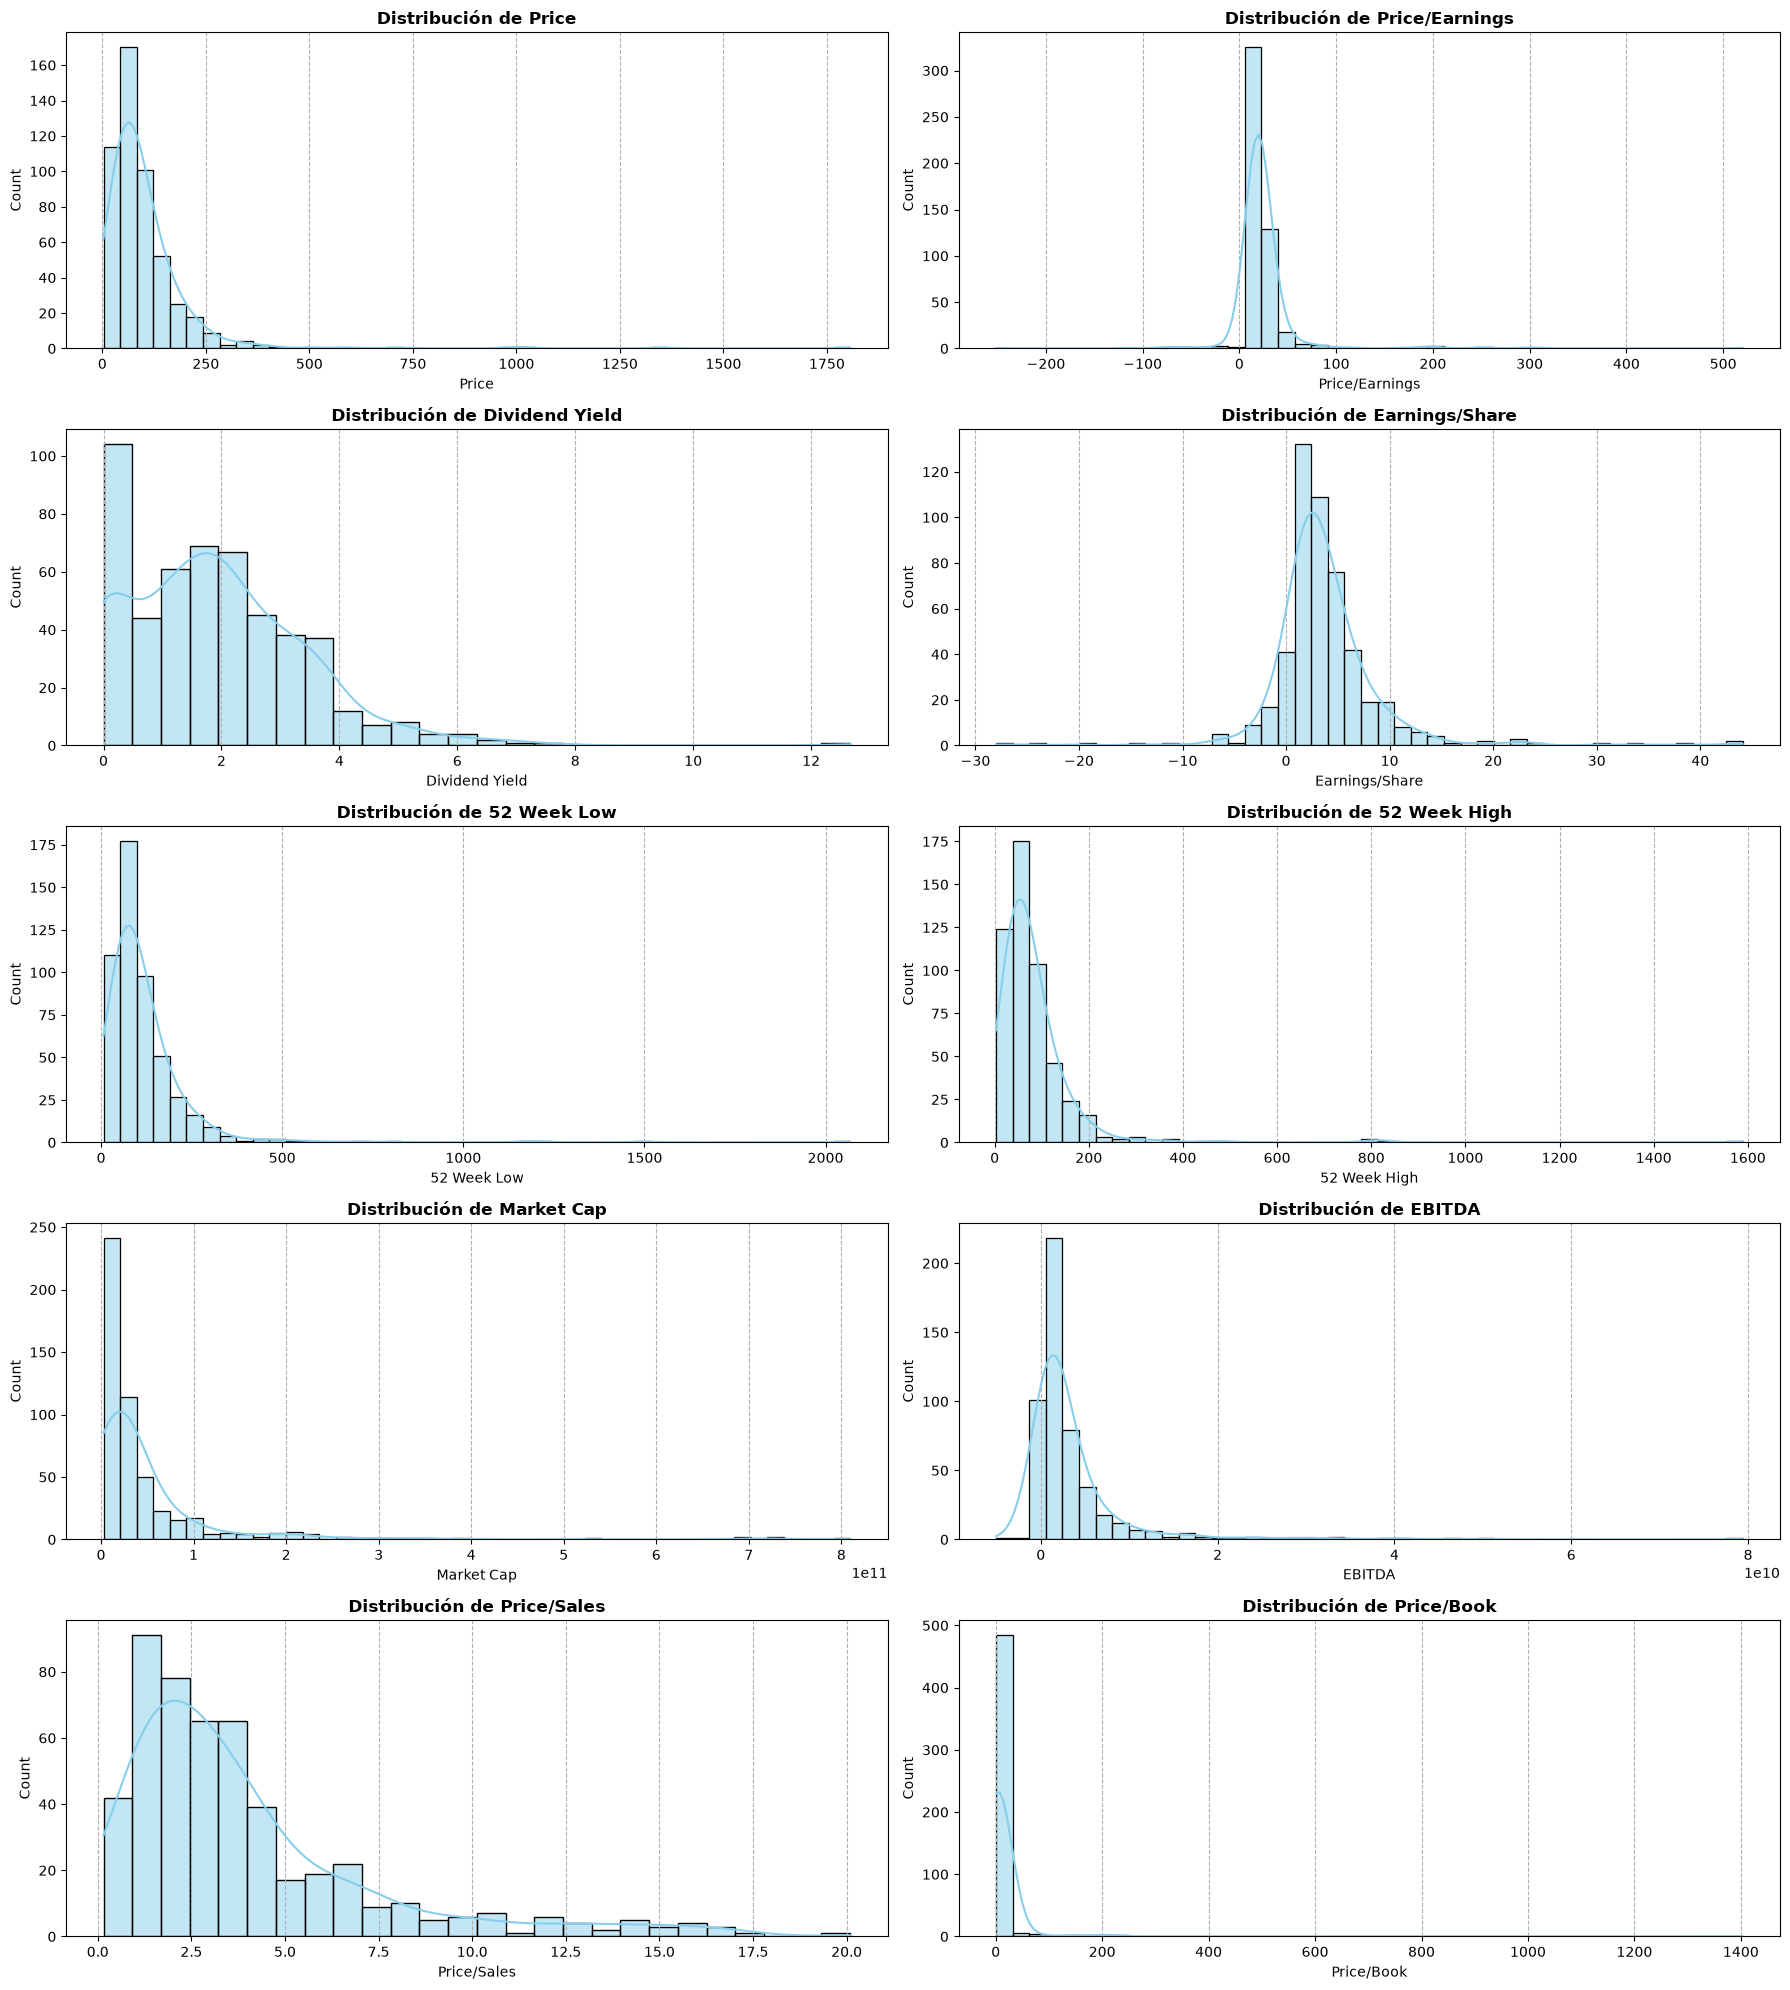

In [15]:
#Histogramas de variables cuantitativas
# Filtrado de las columnas con datos numéricos
#columnas_num = df.select_dtypes(include=['number']).columns
#num_columnas = len(columnas_num)

# Cuadrícula con 3 gráficos por fila
filas = math.ceil(num_columnas / 2)
fig, axes = plt.subplots(filas, 2, figsize=(18, filas * 4))
axes = axes.flatten()

for i, col in enumerate(columnas_num):
    sns.histplot(df[col], ax=axes[i], kde=True, color='skyblue')
    axes[i].set_title(f'Distribución de {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].grid(axis='x', linestyle='--', alpha=1)


plt.tight_layout()
plt.show()

In [16]:
#Normalización de valores
#RobustScaler para evitar la distorsión de los outliers durante la normalización
scaler = RobustScaler()
variables_financieras = ['Price', 'Price/Earnings', 'Dividend Yield', 'Earnings/Share', 'Market Cap', 'EBITDA', 'Price/Sales', 'Price/Book']
valores_escalados = scaler.fit_transform(df[variables_financieras])
df_escalado = pd.DataFrame(valores_escalados, columns=variables_financieras, index=df.index)

In [17]:
# Distribuciones por sector
#'Price', 'Price/Earnings', 'Dividend Yield', 'Earnings/Share', 'Market Cap', 'EBITDA', 'Price/Sales', 'Price/Book'

In [18]:
fig = px.box(df, x="Price", y="Sector", color="Sector",
             title="Análisis Interactivo de P/E por Sector",
             hover_data=["Symbol"], points="outliers")
# "Name"

fig.update_layout(showlegend=False, margin=dict(l=150, r=20, t=50, b=50))
fig.show()

In [19]:
fig = px.box(df, x="Price/Earnings", y="Sector", color="Sector",
             title="Análisis Interactivo de P/E por Sector",
             hover_data=["Symbol"], points="outliers")
# "Name"

fig.update_layout(showlegend=False, margin=dict(l=150, r=20, t=50, b=50))
fig.show()

In [20]:
fig = px.box(df, x="Dividend Yield", y="Sector", color="Sector",
             title="Análisis Interactivo de P/E por Sector",
             hover_data=["Symbol"], points="outliers")
# "Name"

fig.update_layout(showlegend=False, margin=dict(l=150, r=20, t=50, b=50))
fig.show()

In [21]:
fig = px.box(df, x="Earnings/Share", y="Sector", color="Sector",
             title="Análisis Interactivo de P/E por Sector",
             hover_data=["Symbol"], points="outliers")
# "Name"

fig.update_layout(showlegend=False, margin=dict(l=150, r=20, t=50, b=50))
fig.show()

In [22]:
fig = px.box(df, x="Market Cap", y="Sector", color="Sector",
             title="Análisis Interactivo de P/E por Sector",
             hover_data=["Symbol"], points="outliers")
# "Name"

fig.update_layout(showlegend=False, margin=dict(l=150, r=20, t=50, b=50))
fig.show()

In [23]:
fig = px.box(df, x="EBITDA", y="Sector", color="Sector",
             title="Análisis Interactivo de P/E por Sector",
             hover_data=["Symbol"], points="outliers")
# "Name"

fig.update_layout(showlegend=False, margin=dict(l=150, r=20, t=50, b=50))
fig.show()

In [24]:
fig = px.box(df, x="Price/Sales", y="Sector", color="Sector",
             title="Análisis Interactivo de P/E por Sector",
             hover_data=["Symbol"], points="outliers")
# "Name"

fig.update_layout(showlegend=False, margin=dict(l=150, r=20, t=50, b=50))
fig.show()

In [25]:
fig = px.box(df, x="Price/Book", y="Sector", color="Sector",
             title="Análisis Interactivo de P/E por Sector",
             hover_data=["Symbol"], points="outliers")
# "Name"

fig.update_layout(showlegend=False, margin=dict(l=150, r=20, t=50, b=50))
fig.show()

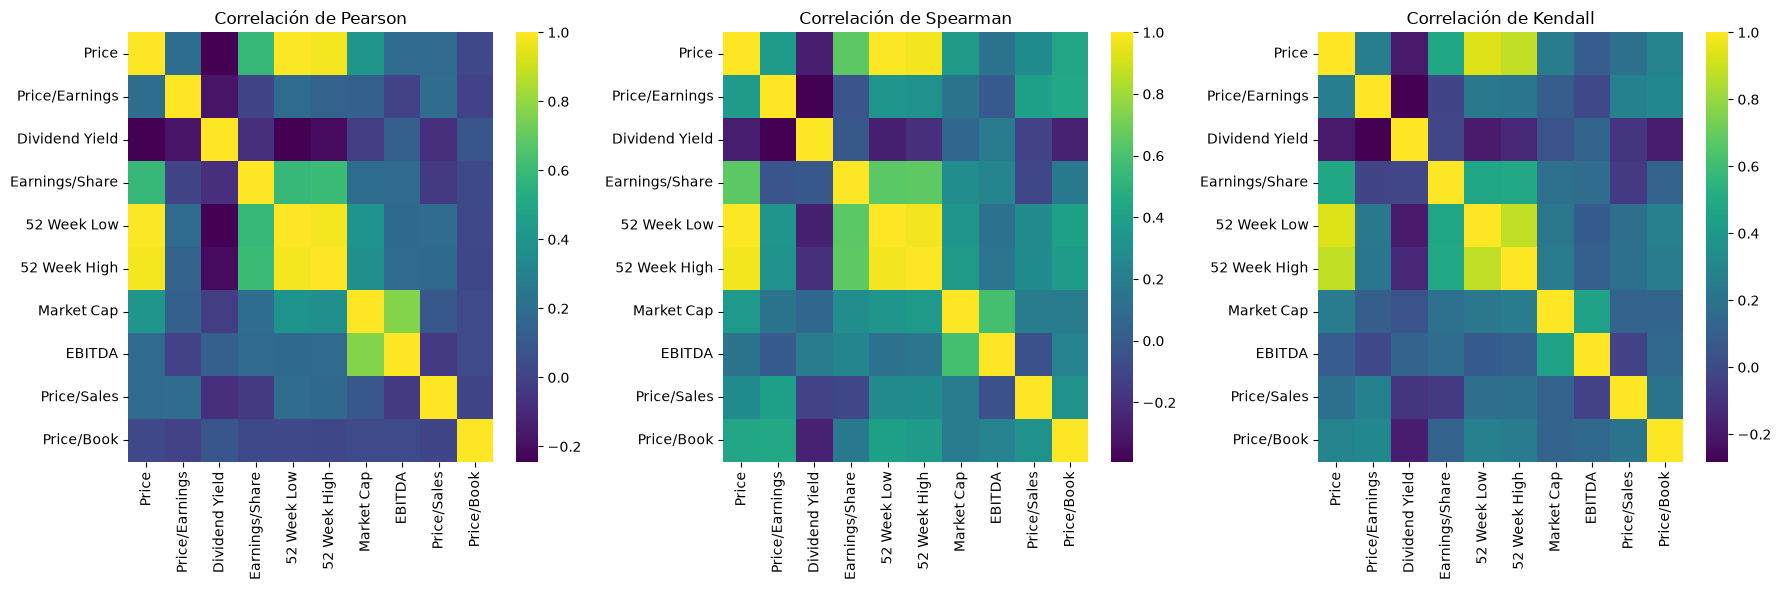

In [26]:
df_corr = df.copy()
df_corr.drop(columns=['Symbol', 'Name', 'Sector', 'SEC Filings'], inplace=True)

fig, axs = plt.subplots(ncols=3, nrows=1, figsize=(18, 6))

sns.heatmap(df_corr.corr(), ax=axs[0], annot=False, cmap='viridis')
axs[0].set_title('Correlación de Pearson')

sns.heatmap(df_corr.corr(method='spearman'), ax=axs[1], annot=False, cmap='viridis')
axs[1].set_title('Correlación de Spearman')

sns.heatmap(df_corr.corr(method='kendall'), ax=axs[2], annot=False, cmap='viridis')
axs[2].set_title('Correlación de Kendall')

plt.tight_layout()
plt.show()
